# Chapter 1.5: Deep Learning Building Blocks for RecSys

## Learning Objectives

By the end of this notebook, you will be able to:

1. Build MLPs for feature interaction in recommendation models
2. Implement scaled dot-product and multi-head attention from scratch
3. Apply 1D CNN and GRU for modeling user behavior sequences
4. Compare pooling strategies: mean, max, and attention-weighted
5. Implement and compare common RecSys loss functions: BCE, BPR, softmax CE, sampled softmax
6. Understand which building block is suited for which recommendation scenario
7. Compose building blocks into a simple recommendation model

## Prerequisites

- Chapter 1.4: Embedding Fundamentals
- PyTorch basics (nn.Module, tensors, autograd)
- Linear algebra (matrix multiplication, softmax)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_system/blob/main/notebooks/part1/chapter_1.5_dl_building_blocks.ipynb)
[![Download](https://img.shields.io/badge/Download-Notebook-blue)](https://github.com/hideak1/rec_system/raw/main/notebooks/part1/chapter_1.5_dl_building_blocks.ipynb)

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import math

np.random.seed(42)
torch.manual_seed(42)

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True

print(f"PyTorch version: {torch.__version__}")
print("All imports successful!")

PyTorch version: 2.2.2
All imports successful!


## 1. MLP for Feature Interaction

The Multi-Layer Perceptron (MLP) is the workhorse of deep RecSys. It learns non-linear feature interactions:

$$
\mathbf{h}_1 = \text{ReLU}(W_1 [\mathbf{e}_u; \mathbf{e}_i; \mathbf{x}] + b_1)
$$
$$
\mathbf{h}_2 = \text{ReLU}(W_2 \mathbf{h}_1 + b_2)
$$
$$
\hat{y} = \sigma(W_3 \mathbf{h}_2 + b_3)
$$

where $[;]$ denotes concatenation and $\mathbf{x}$ represents additional features.

> **💡 Concept:** The MLP implicitly learns feature crosses. A two-layer MLP can learn all pairwise interactions, but deeper networks are needed for higher-order interactions. However, MLPs learn interactions inefficiently compared to explicit methods.

In [2]:
class RecSysMLP(nn.Module):
    """MLP for user-item interaction prediction."""
    
    def __init__(self, n_users, n_items, emb_dim=32, hidden_dims=[64, 32]):
        super().__init__()
        self.user_emb = nn.Embedding(n_users, emb_dim)
        self.item_emb = nn.Embedding(n_items, emb_dim)
        
        layers = []
        input_dim = emb_dim * 2  # Concatenated user + item embeddings
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(input_dim, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.2))
            input_dim = hidden_dim
        layers.append(nn.Linear(input_dim, 1))
        
        self.mlp = nn.Sequential(*layers)
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, std=0.01)
    
    def forward(self, user_ids, item_ids):
        user_vec = self.user_emb(user_ids)
        item_vec = self.item_emb(item_ids)
        x = torch.cat([user_vec, item_vec], dim=-1)
        return self.mlp(x).squeeze(-1)


# Quick test
n_users, n_items = 100, 50
model = RecSysMLP(n_users, n_items)
user_ids = torch.randint(0, n_users, (16,))
item_ids = torch.randint(0, n_items, (16,))
output = model(user_ids, item_ids)
print(f"MLP output shape: {output.shape}")
print(f"Sample predictions: {output[:5].detach().numpy()}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

MLP output shape: torch.Size([16])
Sample predictions: [0.00231856 0.0107539  0.01072394 0.00850842 0.00984436]
Total parameters: 11,073


## 2. Attention Mechanisms

### Scaled Dot-Product Attention

$$
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V
$$

The scaling factor $\sqrt{d_k}$ prevents the dot products from growing too large, which would push the softmax into regions with tiny gradients.

### Multi-Head Attention

$$
\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, ..., \text{head}_h) W^O
$$
$$
\text{head}_i = \text{Attention}(QW_i^Q, KW_i^K, VW_i^V)
$$

> **💡 Concept:** In RecSys, attention is used to:
> 1. **Weigh user history items** differently based on the candidate item (target attention)
> 2. **Self-attention** over user behavior sequence (like in SASRec)
> 3. **Cross-attention** between user features and item features

Input shape: torch.Size([4, 8, 32])
Self-attention output shape: torch.Size([4, 8, 32])


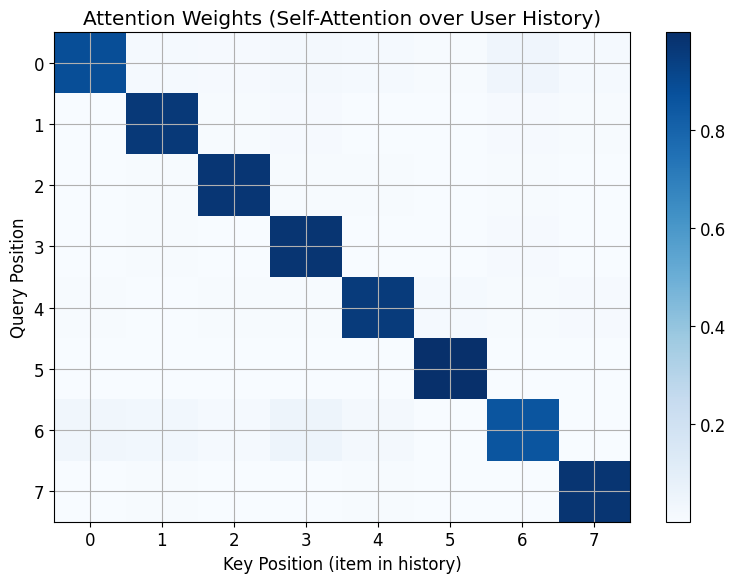

In [3]:
class ScaledDotProductAttention(nn.Module):
    """Scaled dot-product attention from 'Attention Is All You Need'."""
    
    def __init__(self, d_k):
        super().__init__()
        self.scale = math.sqrt(d_k)
    
    def forward(self, Q, K, V, mask=None):
        """
        Args:
            Q: (batch, n_queries, d_k)
            K: (batch, n_keys, d_k)
            V: (batch, n_keys, d_v)
            mask: (batch, n_queries, n_keys) or None
        Returns:
            output: (batch, n_queries, d_v)
            weights: (batch, n_queries, n_keys)
        """
        scores = torch.bmm(Q, K.transpose(1, 2)) / self.scale  # (batch, n_q, n_k)
        
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        
        weights = F.softmax(scores, dim=-1)  # (batch, n_q, n_k)
        output = torch.bmm(weights, V)       # (batch, n_q, d_v)
        
        return output, weights


class MultiHeadAttention(nn.Module):
    """Multi-head attention."""
    
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0
        
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        
        self.W_Q = nn.Linear(d_model, d_model)
        self.W_K = nn.Linear(d_model, d_model)
        self.W_V = nn.Linear(d_model, d_model)
        self.W_O = nn.Linear(d_model, d_model)
        
        self.attention = ScaledDotProductAttention(self.d_k)
    
    def forward(self, Q, K, V, mask=None):
        batch_size = Q.size(0)
        
        # Linear projections and reshape for multi-head
        Q = self.W_Q(Q).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        K = self.W_K(K).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        V = self.W_V(V).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        
        # Reshape for batch attention: (batch*heads, seq_len, d_k)
        Q = Q.reshape(batch_size * self.n_heads, -1, self.d_k)
        K = K.reshape(batch_size * self.n_heads, -1, self.d_k)
        V = V.reshape(batch_size * self.n_heads, -1, self.d_k)
        
        if mask is not None:
            mask = mask.unsqueeze(1).repeat(1, self.n_heads, 1, 1)
            mask = mask.reshape(batch_size * self.n_heads, mask.size(2), mask.size(3))
        
        output, weights = self.attention(Q, K, V, mask)
        
        # Reshape back
        output = output.view(batch_size, self.n_heads, -1, self.d_k)
        output = output.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        
        return self.W_O(output)


# Demo: attention over user behavior sequence
batch_size = 4
seq_len = 8
d_model = 32

# Simulated user behavior sequence embeddings
behavior_seq = torch.randn(batch_size, seq_len, d_model)

# Self-attention
mha = MultiHeadAttention(d_model, n_heads=4)
output = mha(behavior_seq, behavior_seq, behavior_seq)
print(f"Input shape: {behavior_seq.shape}")
print(f"Self-attention output shape: {output.shape}")

# Visualize attention weights for one sample
attn = ScaledDotProductAttention(d_model)
_, weights = attn(behavior_seq, behavior_seq, behavior_seq)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(weights[0].detach().numpy(), cmap='Blues', aspect='auto')
ax.set_xlabel('Key Position (item in history)')
ax.set_ylabel('Query Position')
ax.set_title('Attention Weights (Self-Attention over User History)')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 3. Sequence Modeling: CNN and RNN/GRU

User behavior is sequential. We can model it with:

### 1D CNN
Captures local patterns (e.g., consecutive purchases).

### GRU (Gated Recurrent Unit)
Captures long-range dependencies with gating:

$$
z_t = \sigma(W_z [h_{t-1}, x_t]) \quad \text{(update gate)}
$$
$$
r_t = \sigma(W_r [h_{t-1}, x_t]) \quad \text{(reset gate)}
$$
$$
\tilde{h}_t = \tanh(W [r_t \odot h_{t-1}, x_t]) \quad \text{(candidate)}
$$
$$
h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t \quad \text{(output)}
$$

> **⚠️ Common Pitfall:** RNNs struggle with very long sequences due to vanishing gradients. For user histories with hundreds of items, consider using the last N items or attention-based methods instead.

In [4]:
class SequenceEncoder(nn.Module):
    """Compare CNN vs GRU for encoding user behavior sequences."""
    
    def __init__(self, n_items, emb_dim=32, hidden_dim=64, method='gru'):
        super().__init__()
        self.item_emb = nn.Embedding(n_items, emb_dim, padding_idx=0)
        self.method = method
        
        if method == 'gru':
            self.encoder = nn.GRU(emb_dim, hidden_dim, batch_first=True)
        elif method == 'cnn':
            self.encoder = nn.Sequential(
                nn.Conv1d(emb_dim, hidden_dim, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=1),
                nn.ReLU(),
            )
        
        self.output_dim = hidden_dim
    
    def forward(self, item_seq):
        """
        Args:
            item_seq: (batch, seq_len) item IDs
        Returns:
            (batch, hidden_dim) sequence representation
        """
        emb = self.item_emb(item_seq)  # (batch, seq_len, emb_dim)
        
        if self.method == 'gru':
            output, hidden = self.encoder(emb)
            return hidden.squeeze(0)  # Last hidden state
        elif self.method == 'cnn':
            # Conv1d expects (batch, channels, length)
            x = emb.transpose(1, 2)
            x = self.encoder(x)  # (batch, hidden_dim, seq_len)
            return x.max(dim=2)[0]  # Max pooling over time


# Compare outputs
n_items_demo = 100
seq = torch.randint(1, n_items_demo, (4, 10))

gru_encoder = SequenceEncoder(n_items_demo, method='gru')
cnn_encoder = SequenceEncoder(n_items_demo, method='cnn')

gru_out = gru_encoder(seq)
cnn_out = cnn_encoder(seq)

print(f"Input sequence shape: {seq.shape}")
print(f"GRU output shape: {gru_out.shape}")
print(f"CNN output shape: {cnn_out.shape}")
print(f"\nGRU parameters: {sum(p.numel() for p in gru_encoder.parameters()):,}")
print(f"CNN parameters: {sum(p.numel() for p in cnn_encoder.parameters()):,}")

Input sequence shape: torch.Size([4, 10])
GRU output shape: torch.Size([4, 64])
CNN output shape: torch.Size([4, 64])

GRU parameters: 22,016
CNN parameters: 21,760


## 4. Pooling Strategies

When we have a set/sequence of embeddings (e.g., user's historical items), we need to aggregate them into a single vector.

### Mean Pooling
$$
\mathbf{h} = \frac{1}{|S|} \sum_{i \in S} \mathbf{e}_i
$$

### Max Pooling
$$
h_j = \max_{i \in S} e_{ij} \quad \text{(element-wise max)}
$$

### Attention-Weighted Pooling (Target Attention)
$$
\alpha_i = \frac{\exp(\mathbf{e}_i \cdot \mathbf{e}_{\text{target}})}{\sum_{j \in S} \exp(\mathbf{e}_j \cdot \mathbf{e}_{\text{target}})}
$$
$$
\mathbf{h} = \sum_{i \in S} \alpha_i \mathbf{e}_i
$$

> **🔑 Pro Tip:** Attention-weighted pooling (as used in DIN - Deep Interest Network) is the most powerful because it makes the user representation *adaptive* to the target item. A user who bought both hiking gear and cooking supplies will be represented differently when seeing a tent vs. a pan.

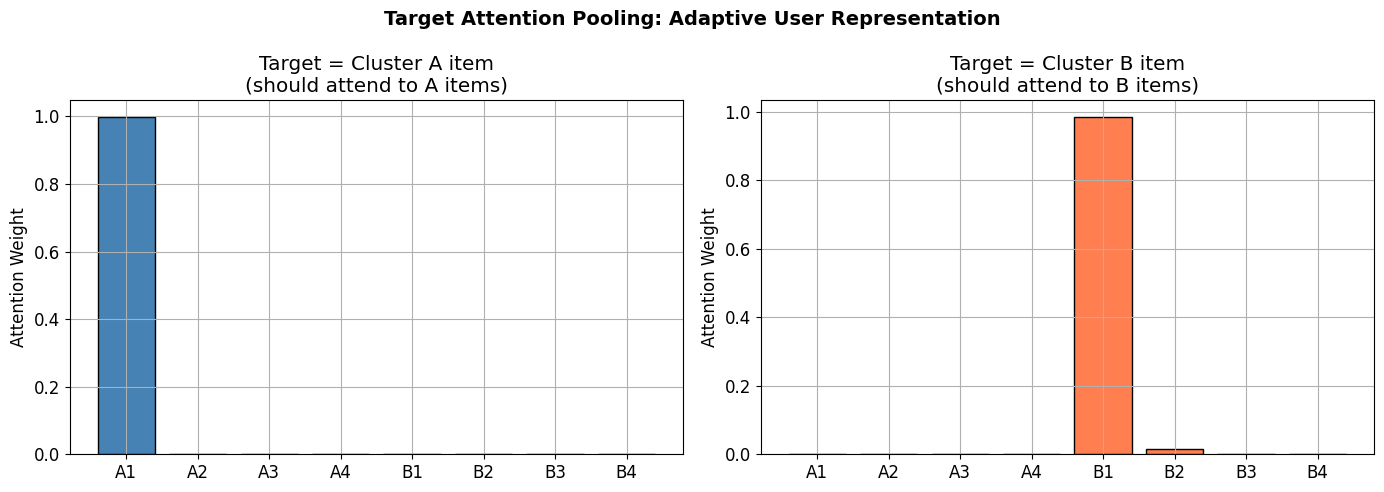

The attention distribution shifts based on the target item!
This is the key idea behind DIN (Deep Interest Network).


In [5]:
class PoolingComparison(nn.Module):
    """Compare different pooling strategies."""
    
    def __init__(self, emb_dim):
        super().__init__()
        self.emb_dim = emb_dim
        # Learnable attention for self-attention pooling
        self.attn_query = nn.Linear(emb_dim, emb_dim)
    
    def mean_pool(self, embeddings, mask=None):
        if mask is not None:
            embeddings = embeddings * mask.unsqueeze(-1)
            return embeddings.sum(dim=1) / mask.sum(dim=1, keepdim=True).clamp(min=1)
        return embeddings.mean(dim=1)
    
    def max_pool(self, embeddings, mask=None):
        if mask is not None:
            embeddings = embeddings.masked_fill(~mask.unsqueeze(-1).bool(), -1e9)
        return embeddings.max(dim=1)[0]
    
    def attention_pool(self, embeddings, target, mask=None):
        """Target attention pooling."""
        # (batch, seq_len, dim) x (batch, dim, 1) -> (batch, seq_len, 1)
        scores = torch.bmm(embeddings, target.unsqueeze(2)).squeeze(2)
        scores = scores / math.sqrt(self.emb_dim)
        
        if mask is not None:
            scores = scores.masked_fill(~mask.bool(), -1e9)
        
        weights = F.softmax(scores, dim=1)  # (batch, seq_len)
        # Weighted sum
        output = torch.bmm(weights.unsqueeze(1), embeddings).squeeze(1)  # (batch, dim)
        return output, weights


# Demo: different pooling on user history
emb_dim = 32
pooling = PoolingComparison(emb_dim)

# Simulate: user history of 8 items with 2 distinct interest clusters
torch.manual_seed(42)
cluster_a = torch.randn(1, 4, emb_dim) + torch.randn(1, 1, emb_dim)  # 4 items from cluster A
cluster_b = torch.randn(1, 4, emb_dim) + torch.randn(1, 1, emb_dim) * 2  # 4 items from cluster B
history = torch.cat([cluster_a, cluster_b], dim=1)  # (1, 8, 32)

# Two different target items - one similar to cluster A, one to cluster B
target_a = cluster_a[0, 0]  # Similar to cluster A
target_b = cluster_b[0, 0]  # Similar to cluster B

mean_out = pooling.mean_pool(history)
max_out = pooling.max_pool(history)
attn_out_a, weights_a = pooling.attention_pool(history, target_a.unsqueeze(0))
attn_out_b, weights_b = pooling.attention_pool(history, target_b.unsqueeze(0))

# Visualize attention weights
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

positions = range(8)
labels = ['A1', 'A2', 'A3', 'A4', 'B1', 'B2', 'B3', 'B4']
colors = ['steelblue'] * 4 + ['coral'] * 4

axes[0].bar(positions, weights_a[0].detach().numpy(), color=colors, edgecolor='black')
axes[0].set_xticks(positions)
axes[0].set_xticklabels(labels)
axes[0].set_ylabel('Attention Weight')
axes[0].set_title('Target = Cluster A item\n(should attend to A items)')

axes[1].bar(positions, weights_b[0].detach().numpy(), color=colors, edgecolor='black')
axes[1].set_xticks(positions)
axes[1].set_xticklabels(labels)
axes[1].set_ylabel('Attention Weight')
axes[1].set_title('Target = Cluster B item\n(should attend to B items)')

plt.suptitle('Target Attention Pooling: Adaptive User Representation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("The attention distribution shifts based on the target item!")
print("This is the key idea behind DIN (Deep Interest Network).")

## 5. Loss Functions for RecSys

### Binary Cross-Entropy (BCE)
For CTR prediction (pointwise):
$$
\mathcal{L}_{\text{BCE}} = -\frac{1}{N} \sum_{i=1}^{N} [y_i \log \hat{y}_i + (1 - y_i) \log(1 - \hat{y}_i)]
$$

### BPR Loss
For pairwise ranking:
$$
\mathcal{L}_{\text{BPR}} = -\frac{1}{N} \sum_{i=1}^{N} \log \sigma(\hat{r}_{\text{pos}} - \hat{r}_{\text{neg}})
$$

### Softmax Cross-Entropy
For listwise ranking (treat as classification over all items):
$$
\mathcal{L}_{\text{softmax}} = -\log \frac{\exp(s_{\text{pos}})}{\sum_{j} \exp(s_j)}
$$

### Sampled Softmax
Approximate full softmax with negative sampling (essential for large item catalogs):
$$
\mathcal{L}_{\text{sampled}} = -\log \frac{\exp(s_{\text{pos}})}{\exp(s_{\text{pos}}) + \sum_{j \in \text{neg\_samples}} \exp(s_j)}
$$

> **⚠️ Common Pitfall:** Sampled softmax requires correction for the sampling probability to be an unbiased estimator. Without correction, popular items get unfairly penalized. See the `log_correction` term below.

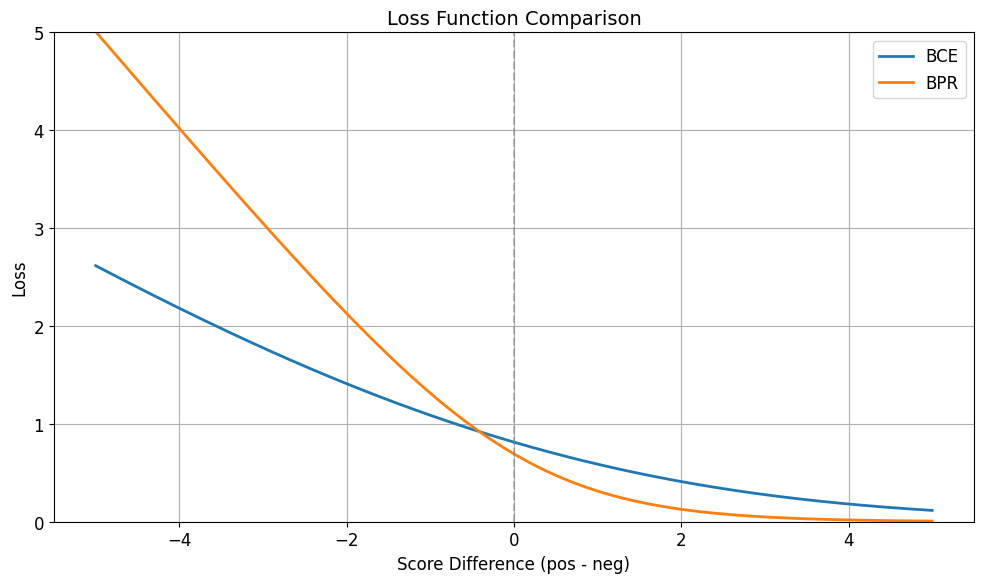

BCE treats positive and negative independently.
BPR directly optimizes the difference between positive and negative scores.


In [6]:
def bce_loss(pos_scores, neg_scores):
    """Binary cross-entropy loss."""
    pos_loss = -torch.log(torch.sigmoid(pos_scores) + 1e-10)
    neg_loss = -torch.log(1 - torch.sigmoid(neg_scores) + 1e-10)
    return (pos_loss.mean() + neg_loss.mean()) / 2


def bpr_loss(pos_scores, neg_scores):
    """BPR pairwise ranking loss."""
    return -torch.log(torch.sigmoid(pos_scores - neg_scores) + 1e-10).mean()


def sampled_softmax_loss(pos_scores, neg_scores):
    """
    Sampled softmax loss.
    pos_scores: (batch,)
    neg_scores: (batch, n_neg)
    """
    # Concatenate positive and negative scores
    all_scores = torch.cat([pos_scores.unsqueeze(1), neg_scores], dim=1)  # (batch, 1+n_neg)
    # Target is always index 0 (the positive)
    targets = torch.zeros(pos_scores.size(0), dtype=torch.long)
    return F.cross_entropy(all_scores, targets)


# Compare loss landscapes
score_diffs = torch.linspace(-5, 5, 200)  # pos_score - neg_score

bce_vals = []
bpr_vals = []
for d in score_diffs:
    pos = torch.tensor([d / 2 + 1.0])
    neg = torch.tensor([-d / 2 + 1.0])
    bce_vals.append(bce_loss(pos, neg).item())
    bpr_vals.append(bpr_loss(pos, neg).item())

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(score_diffs.numpy(), bce_vals, linewidth=2, label='BCE')
ax.plot(score_diffs.numpy(), bpr_vals, linewidth=2, label='BPR')
ax.set_xlabel('Score Difference (pos - neg)', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Loss Function Comparison', fontsize=14)
ax.legend(fontsize=12)
ax.set_ylim(0, 5)
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("BCE treats positive and negative independently.")
print("BPR directly optimizes the difference between positive and negative scores.")

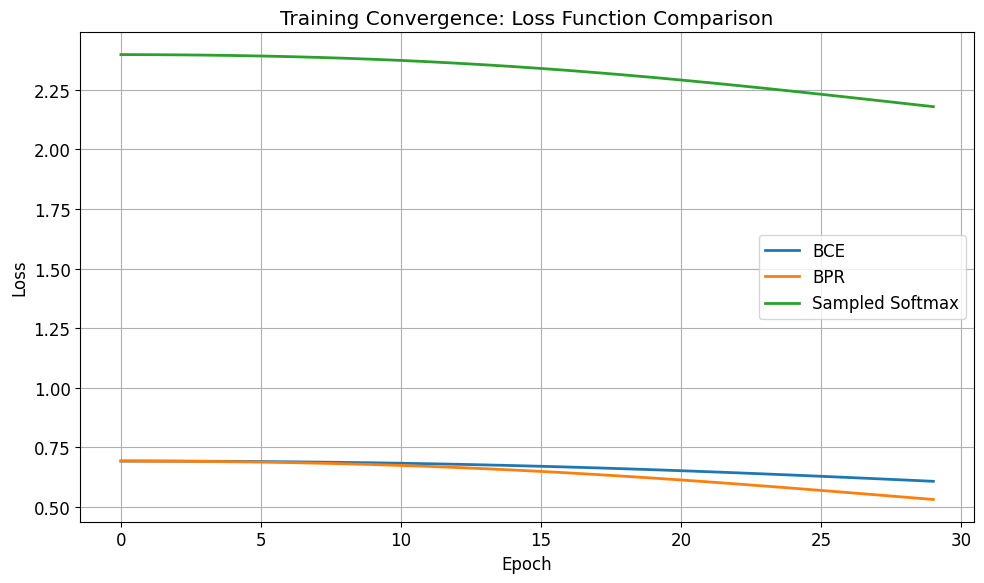

In [7]:
# Train a simple model with different losses and compare convergence
torch.manual_seed(42)
np.random.seed(42)

# Generate synthetic implicit feedback data
n_u, n_i = 200, 100
n_train = 5000
users = torch.randint(0, n_u, (n_train,))
pos_items = torch.randint(0, n_i, (n_train,))
neg_items = torch.randint(0, n_i, (n_train, 10))  # 10 negatives per sample

losses_dict = {}
for loss_name, loss_fn in [('BCE', bce_loss), ('BPR', bpr_loss)]:
    torch.manual_seed(42)
    user_emb = nn.Embedding(n_u, 16)
    item_emb = nn.Embedding(n_i, 16)
    nn.init.normal_(user_emb.weight, std=0.01)
    nn.init.normal_(item_emb.weight, std=0.01)
    
    params = list(user_emb.parameters()) + list(item_emb.parameters())
    opt = optim.Adam(params, lr=0.01)
    
    epoch_losses = []
    for epoch in range(30):
        u_vec = user_emb(users)
        pos_vec = item_emb(pos_items)
        neg_vec = item_emb(neg_items[:, 0])  # Use first negative
        
        pos_scores = (u_vec * pos_vec).sum(dim=1)
        neg_scores = (u_vec * neg_vec).sum(dim=1)
        
        loss = loss_fn(pos_scores, neg_scores)
        opt.zero_grad()
        loss.backward()
        opt.step()
        epoch_losses.append(loss.item())
    
    losses_dict[loss_name] = epoch_losses

# Sampled softmax separately (different input format)
torch.manual_seed(42)
user_emb_ss = nn.Embedding(n_u, 16)
item_emb_ss = nn.Embedding(n_i, 16)
nn.init.normal_(user_emb_ss.weight, std=0.01)
nn.init.normal_(item_emb_ss.weight, std=0.01)
opt_ss = optim.Adam(list(user_emb_ss.parameters()) + list(item_emb_ss.parameters()), lr=0.01)

ss_losses = []
for epoch in range(30):
    u_vec = user_emb_ss(users)
    pos_vec = item_emb_ss(pos_items)
    neg_vecs = item_emb_ss(neg_items)  # (n_train, 10, 16)
    
    pos_scores = (u_vec * pos_vec).sum(dim=1)
    neg_scores = torch.bmm(neg_vecs, u_vec.unsqueeze(2)).squeeze(2)  # (n_train, 10)
    
    loss = sampled_softmax_loss(pos_scores, neg_scores)
    opt_ss.zero_grad()
    loss.backward()
    opt_ss.step()
    ss_losses.append(loss.item())

losses_dict['Sampled Softmax'] = ss_losses

fig, ax = plt.subplots(figsize=(10, 6))
for name, losses in losses_dict.items():
    ax.plot(losses, linewidth=2, label=name)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training Convergence: Loss Function Comparison')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

---

## Exercises

### 🏋️ Exercise 1: Implement Attention-Weighted Pooling for User History

Build a complete model that uses attention-weighted pooling over user history to predict CTR.

In [8]:
class AttentionRecModel(nn.Module):
    """A simple DIN-style model with target attention."""
    
    def __init__(self, n_items, emb_dim=32, hidden_dim=64):
        super().__init__()
        # TODO: Initialize item embedding
        # TODO: Initialize attention MLP (takes concat of history item and target, outputs scalar)
        # TODO: Initialize prediction MLP (takes pooled history and target, outputs CTR)
        pass
    
    def attention_pool(self, history_embs, target_emb, mask=None):
        """
        Args:
            history_embs: (batch, seq_len, emb_dim)
            target_emb: (batch, emb_dim)
            mask: (batch, seq_len) 1=valid, 0=padding
        Returns:
            pooled: (batch, emb_dim)
        """
        # TODO: Implement DIN-style attention
        # 1. Repeat target to match history length
        # 2. Concatenate history and target embeddings
        # 3. Pass through attention MLP to get scores
        # 4. Apply mask and softmax
        # 5. Weighted sum
        pass
    
    def forward(self, history, target, mask=None):
        # TODO: Full forward pass
        pass


# TODO: Generate synthetic data and train the model
# Compare with mean pooling baseline

### 🏋️ Exercise 2: Compare Loss Functions on a Ranking Task

Train the same model architecture with BCE, BPR, and sampled softmax, then evaluate ranking quality.

In [9]:
# TODO:
# 1. Generate synthetic implicit feedback data with known relevant items per user
# 2. Train a simple MF model with each of the three loss functions
# 3. For each model, compute NDCG@10 and HitRate@10
# 4. Create a comparison table and visualization
# 5. Discuss which loss works best and why
pass

### 🏋️ Exercise 3: Build a Hybrid Sequence+Attention Model

Combine GRU encoding with attention pooling.

In [10]:
# TODO:
# 1. Create a model that:
#    - Encodes user history with GRU (captures sequential patterns)
#    - Applies attention over GRU hidden states using the target item (captures relevance)
#    - Feeds the attention output + target embedding into an MLP for prediction
# 2. Compare with GRU-only (last hidden state) and attention-only (no GRU)
# 3. Generate sequential synthetic data where order matters
# 4. Show that the hybrid model captures both order and relevance
pass

## Summary

In this notebook, we covered the essential building blocks:

1. **MLP**: Feature interaction layers - the backbone of deep RecSys
2. **Attention**: Scaled dot-product and multi-head - enables dynamic user representations
3. **CNN/GRU**: Sequence modeling for user behavior - captures temporal patterns
4. **Pooling**: Mean, max, and attention-weighted - how to aggregate sets of embeddings
5. **Loss Functions**: BCE, BPR, softmax, sampled softmax - different optimization objectives

### Key Takeaways

- Attention-weighted pooling is the most powerful aggregation method (DIN)
- BPR and sampled softmax are generally better than BCE for ranking tasks
- GRU captures sequential patterns but attention handles long histories better
- These building blocks combine like LEGO pieces in modern RecSys architectures

### Next Up

In **Chapter 1.6**, we'll learn about feature engineering - how to prepare the raw data that feeds into these building blocks.